# 损失函数

在深度学习广为使用的今天，我们可以在脑海里清晰的知道，一个模型想要达到很好的效果需要学习，也就是我们常说的训练。一个好的训练离不开优质的负反馈，这里的损失函数就是模型的负反馈。

来自 [深入浅出 pytorch - 损失函数](https://datawhalechina.github.io/thorough-pytorch/%E7%AC%AC%E4%B8%89%E7%AB%A0/3.6%20%E6%8D%9F%E5%A4%B1%E5%87%BD%E6%95%B0.html)，下面只展示了最常见的一些损失函数。

In [1]:
import torch
from torch import nn

## 二分类交叉损失

label 一般为 {0, 1}，input 为 [0,1] 的概率。

更具体地，一般来说 label 是独热码（在分类中），input 来自 sigmoid/softmax 等激活层。

```py
torch.nn.BCELoss(weight=None, # tensor, 每个位置的权重
                 size_average=None, # bool, False 返回各样本和，True 返回平均值
                 reduce=None, # bool, True 时返回标量
                 reduction="mean") # None/"mean"/"sum", 返回标量是平均还是求和
```

In [ ]:
# BCELoss
act = nn.Sigmoid() # 激活函数
loss = nn.BCELoss() # 损失函数
ipt = torch.randn(3, requires_grad=True) # 输入
pred = act(ipt) # 预测值
label = torch.rand(3) # 标签
opt = loss(pred, label) # 输出
opt.backward(); opt

tensor(0.6913, grad_fn=<BinaryCrossEntropyBackward0>)

## 交叉熵损失

$$
\mathrm{loss}(x,\mathrm{~class~})=-\log\left(\frac{\exp(x[\mathrm{~class~}]))}{\sum_j\exp(x[j])}\right)=-x[\mathrm{~class~}]+\log\left(\sum_j\exp(x[j])\right)
$$

```py
torch.nn.CrossEntropyLoss(weight=None,
                          size_average=None, 
                          ignore_index=-100, # 忽略某一个 idx 下的损失
                          reduce=None, 
                          reduction='mean')
```

In [ ]:
# CrossEntropyLoss
loss = nn.CrossEntropyLoss()
ipt = torch.randn(3, 5, requires_grad=True)
label = torch.empty(3, dtype=torch.long).random_(5)
opt = loss(ipt, label)
opt.backward(); opt

tensor(1.5613, grad_fn=<NllLossBackward0>)

## （平滑）L1 损失

L1 损失函数即是度量向量之间的 L1范数距离；逐元素有：

$$
l_n = |x_n - y_n|
$$

还有平滑版本：

$$
\mathrm{loss}(x,y)=\frac1n\sum_{i=1}^nz_i\text{ 其中, }z_i=\begin{cases} \frac{1}{2} (x_i-y_i)^2,&\mathrm{~if~}|x_i-y_i|<\beta\\|x_i-y_i|-0.5*\beta,&\mathrm{~otherwise~}&\end{cases}
$$

```py
torch.nn.L1Loss(size_average=None, 
                reduce=None, 
                reduction='mean')

torch.nn.SmoothL1Loss(size_average=None,
                      reduce=None, 
                      reduction='mean', 
                      beta=1.0)
```

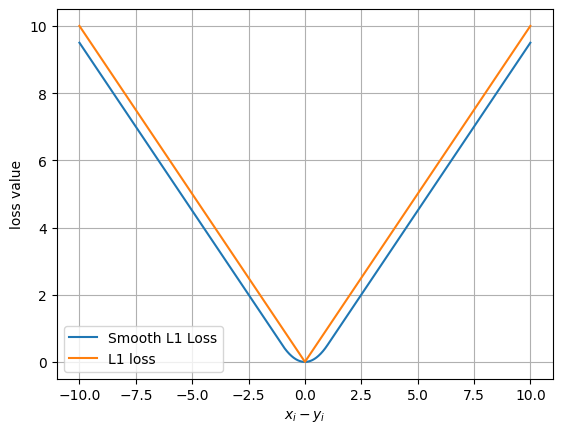

In [8]:
# L1Loss & SmoothL1Loss
inputs = torch.linspace(-10, 10, steps=5000)
target = torch.zeros_like(inputs)

loss_f_smooth = nn.SmoothL1Loss(reduction='none')
loss_smooth = loss_f_smooth(inputs, target)
loss_f_l1 = nn.L1Loss(reduction='none')
loss_l1 = loss_f_l1(inputs,target)
import matplotlib.pyplot as plt
plt.plot(inputs.numpy(), loss_smooth.numpy(), label='Smooth L1 Loss')
plt.plot(inputs.numpy(), loss_l1, label='L1 loss')
plt.xlabel(r'$x_i - y_i$')
plt.ylabel('loss value')
plt.legend()
plt.grid()
plt.show()

## 均方误差损失

计算输入与标签之差的平方：

$$
l_n = (x_n - y_n)^2
$$

```py
torch.nn.MSELoss(size_average=None, 
                 reduce=None, 
                 reduction='mean')
```

In [5]:
# MSELoss
loss = nn.MSELoss()
ipt = torch.randn(3, 5, requires_grad=True)
label = torch.randn(3, 5)
opt = loss(ipt, label)
opt.backward(); opt

tensor(2.4969, grad_fn=<MseLossBackward0>)

## KL 散度

计算 KL 散度，也就是计算相对熵。用于连续分布的距离度量，并且对离散采用的连续输出空间分布进行回归通常很有用。

$$
\begin{aligned}D_{\mathrm{KL}}(P,Q)&=\operatorname{E}_{X\sim P}\left[\log\frac{P(X)}{Q(X)}\right]=\operatorname{E}_{X\sim P}[\log P(X)-\log Q(X)]\\&=\sum_{i=1}^nP\left(x_i\right)\left(\log P\left(x_i\right)-\log Q\left(x_i\right)\right)\end{aligned}
$$

```py
torch.nn.KLDivLoss(size_average=None, 
                   reduce=None, 
                   reduction='mean', # none/"mean"/"sum"/"batchmean"
                   log_target=False)
```

In [ ]:
ipt = torch.tensor([[0.5, 0.3, 0.2], [0.2, 0.3, 0.5]])
label = torch.tensor([[0.9, 0.05, 0.05], [0.1, 0.7, 0.2]], dtype=torch.float)
loss = nn.KLDivLoss(reduction="batchmean") # otherwise, warning!
opt = loss(ipt, label); opt

tensor(-1.0006)

## 边界排序损失

这个损失函数常用于排序任务中，计算公式为：

$$
Loss(x_1, x_2, y) = max(0, -y * (x_1 - x_2) + margin)
$$

其中，$x_1$ 和 $x_2$ 为两个样本的相关性分数，$y$ 为三元组标签（如果 $x_1$ 分数应该高于 $x_2$，则为 1；否则为 -1），$margin$ 为认为至少相差 margin 分数才满意。

```py
torch.nn.MarginRankingLoss(margin=0.0, 
                           size_average=None, 
                           reduce=None, 
                           reduction='mean')
```

In [ ]:
# MarginRankingLoss
loss = nn.MarginRankingLoss()
ipt1 = torch.randn(3, requires_grad=True)
ipt2 = torch.randn(3, requires_grad=True)
label = torch.randn(3).sign()
opt = loss(ipt1, ipt2, label)
opt.backward(); opt

tensor(1.1101, grad_fn=<MeanBackward0>)

## 三元组损失

**三元组**: 这是一种数据的存储或者使用格式。< item1, relationship, item2 >。在项目中，更多表示为 < anchor, positive examples , negative examples>。

在这个损失函数的负反馈下，我们期望 anchor 靠近 positive examples，而远离 negative examples。

$$
L(a,p,n)=\max\left\{d\left(a_i,p_i\right)-d\left(a_i,n_i\right)+\text{margin},0\right\}, \\\text{s.t. } d(x_i, y_i) = \|x_i-y_i\|_p, p \in \{1, 2\}
$$

```py
torch.nn.TripletMarginLoss(margin=1.0, 
                           p=2.0, # 1/2, 范数
                           eps=1e-06, # 误差
                           swap=False, 
                           size_average=None, 
                           reduce=None, 
                           reduction='mean')
```

In [ ]:
# TripletMarginLoss
loss = nn.TripletMarginLoss(margin=1.0, p=2)
anchor = torch.randn(100, 128, requires_grad=True)
positive = torch.randn(100, 128, requires_grad=True)
negative = torch.randn(100, 128, requires_grad=True)
output = loss(anchor, positive, negative)
output.backward(); output

tensor(1.0980, grad_fn=<MeanBackward0>)

## 余弦相似度损失

计算两个向量之间的余弦值作为距离，进而引出余弦相似度。输入同样是一个三元组：

$$
\begin{aligned}&\operatorname{loss}(x_1, x_2, y)=\begin{cases}1-\cos{(x_1,x_2)},&\mathrm{~if~}y=1\\\max{\{0,\cos{(x_1,x_2)}-\mathrm{~margin~}\}},&\mathrm{~if~}y=-1&\end{cases}\\&\text{其中,}\cos(A, B)=\frac{A\cdot B}{\|A\|\|B\|}=\frac{\sum_{i=1}^nA_i\times B_i}{\sqrt{\sum_{i=1}^n\left(A_i\right)^2}\times\sqrt{\sum_{i=1}^n\left(B_i\right)^2}}\end{aligned}
$$

```py
torch.nn.CosineEmbeddingLoss(margin=0.0, 
                             size_average=None, 
                             reduce=None, 
                             reduction='mean')
```

In [15]:
loss = nn.CosineEmbeddingLoss()
ipt1 = torch.tensor([[0.3, 0.5, 0.7], [0.3, 0.5, 0.7]])
ipt2 = torch.tensor([[0.1, 0.3, 0.5], [0.1, 0.3, 0.5]])
label = torch.tensor([1, -1], dtype=torch.float)
output = loss(ipt1,ipt2, label); output

tensor(0.5000)

## 自定义损失函数

有时候我们需要自定义损失函数，比如在训练过程中，我们希望将预测结果与标签进行比较，但是标签的维度和预测结果维度不一致，这时我们就需要自定义损失函数。

简单情况下我们使用一个函数计算损失即可：

```python
def my_loss(output, target):
    loss = torch.mean((output - target)**2)
    return loss
```

但是以类方式定义更加常用，在以类方式定义损失函数时，我们如果看每一个损失函数的继承关系我们就可以发现最终继承自 `nn.Module` 类，因此可以将其作为神经网络的一层来看待。

以 Dice Loss ($DSC=\frac{2|X\cap Y|}{|X|+|Y|}$) 为例，其基本实现如下（更多参考 [kaggle 上的这篇文章](https://www.kaggle.com/code/bigironsphere/loss-function-library-keras-pytorch/notebook) ）：

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self,weight=None,size_average=True):
        super(DiceLoss,self).__init__()
        
    def forward(self,inputs,targets,smooth=1):
        inputs = F.sigmoid(inputs)       
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()                   
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        return 1 - dice

# 使用方法    
criterion = DiceLoss()
loss = criterion(input,targets)